In [1]:
import pandas as pd
import glob,os

#############################################################################
######### CHANGE INPUT FOLDER FILE HERE #####################################
#############################################################################
file_path = r"C:\Research-Paper\PAPER-WORK-2024\SQL-Databse-Execution-Test-Dataset\Spider-Data-1__query_evaluation.xlsx"
# Read the excel file
df = pd.read_excel(file_path, engine='openpyxl')
df.head()

,db_id,spider_query,question,text2sql_query,spider_query_length,text2sql_query_length,query_len_match,target_operations_counts,predicted_operations_counts,matching_counts,...,operations_similarity,hallucinations_in_operations_selection,query_similarity,hallucinations_in_query,normalized_target_query,target_data_length,target_execution_status,predicted_data_length,predicted_execution_status,execution_result
0,farm,"SELECT count(*) FROM ""farm"";",How many farms are there?,"SELECT COUNT(*) FROM ""farm"" f;",28,30,False,"Counter({'SELECT': 1, 'FROM': 1, 'JOIN': 0, 'W...","Counter({'SELECT': 1, 'FROM': 1, 'JOIN': 0, 'W...",11,...,1.0,False,1.00,False,"SELECT count(*)\nFROM ""farm"";",1,True,1,True,True
1,farm,"SELECT count(*) FROM ""farm"";",Count the number of farms.,SELECT COUNT(*) FROM farm;,28,26,False,"Counter({'SELECT': 1, 'FROM': 1, 'JOIN': 0, 'W...","Counter({'SELECT': 1, 'FROM': 1, 'JOIN': 0, 'W...",11,...,1.0,False,1.00,False,"SELECT count(*)\nFROM ""farm"";",1,True,1,True,True
2,farm,"SELECT ""Total_Horses"" FROM ""farm"" ORDER BY ""To...",List the total number of horses on farms in as...,"SELECT f.""Farm_ID"", f.""Total_Horses"" FROM ""far...",62,81,False,"Counter({'SELECT': 1, 'FROM': 1, 'ORDER BY': 1...","Counter({'SELECT': 1, 'FROM': 1, 'ORDER BY': 1...",11,...,1.0,False,0.67,True,"SELECT ""Total_Horses""\nFROM ""farm""\nORDER BY ""...",8,True,8,True,False
3,farm,"SELECT ""Total_Horses"" FROM ""farm"" ORDER BY ""To...","What is the total horses record for each farm,...","SELECT f.""Farm_ID"", f.""Total_Horses"" FROM ""far...",62,81,False,"Counter({'SELECT': 1, 'FROM': 1, 'ORDER BY': 1...","Counter({'SELECT': 1, 'FROM': 1, 'ORDER BY': 1...",11,...,1.0,False,0.67,True,"SELECT ""Total_Horses""\nFROM ""farm""\nORDER BY ""...",8,True,8,True,False
4,farm,"SELECT ""Hosts"" FROM ""farm_competition"" WHERE ""...",What are the hosts of competitions whose theme...,SELECT DISTINCT fc.Hosts FROM farm_competition...,68,76,False,"Counter({'SELECT': 1, 'FROM': 1, 'WHERE': 1, '...","Counter({'SELECT': 1, 'FROM': 1, 'WHERE': 1, '...",11,...,1.0,False,0.67,True,"SELECT ""Hosts""\nFROM ""farm_competition""\nWHERE...",6,True,0,False,False


In [2]:
df.shape

(719, 49)

In [3]:
percentage_true = (df['execution_result'].sum() / len(df['execution_result'])) * 100
print(f"Percentage of execution_result value: {percentage_true:.2f}%")

Percentage of execution_result value: 19.19%


In [4]:
execution_result_list = []

for i in range(1,8):
    file_path = r"C:\Research-Paper\PAPER-WORK-2024\SQL-Databse-Execution-Test-Dataset\Spider-Data-"+str(i)+"__query_evaluation.xlsx"
    # Read the excel file
    df = pd.read_excel(file_path, engine='openpyxl')
    print("#"*100)
    print("Spider-Data-"+str(i)+"__query_evaluation.xlsx")
    percentage_true = (df['execution_result'].sum() / len(df['execution_result'])) * 100
    print(f"Percentage of execution_result value: {percentage_true:.2f}%")
    execution_result_list.append(percentage_true)
    print("#"*100)

####################################################################################################
Spider-Data-1__query_evaluation.xlsx
Percentage of execution_result value: 19.19%
####################################################################################################
####################################################################################################
Spider-Data-2__query_evaluation.xlsx
Percentage of execution_result value: 24.48%
####################################################################################################
####################################################################################################
Spider-Data-3__query_evaluation.xlsx
Percentage of execution_result value: 23.23%
####################################################################################################
####################################################################################################
Spider-Data-4__query_evaluation.xlsx
Percentage

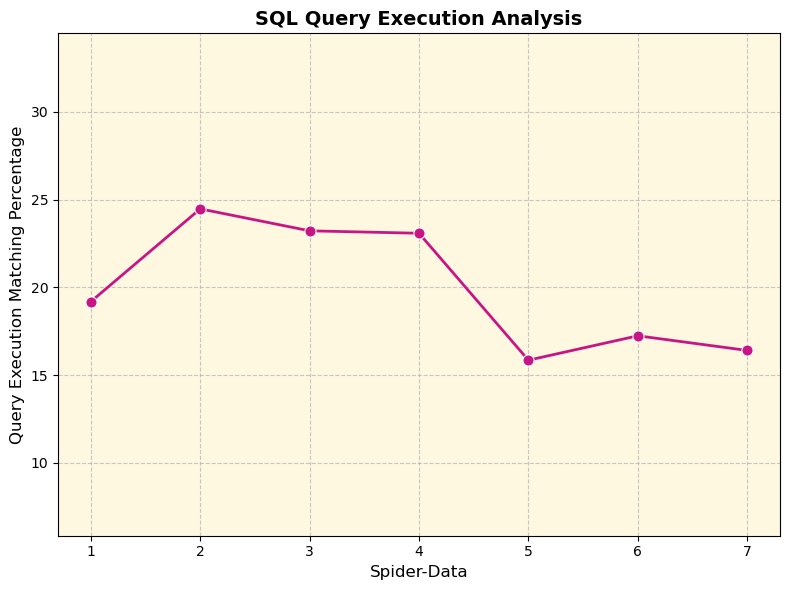

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create a DataFrame for Seaborn
import pandas as pd
df = pd.DataFrame({'Index': [1,2,3,4,5,6,7], 'Value': execution_result_list})

# Plot the line chart
plt.figure(figsize=(8, 6))  # Set figure size for better readability
sns.lineplot(data=df, x='Index', y='Value', marker='o', color='#C71585', linewidth=2, markersize=8)

# Change background color of the plot area (inside the plot)
plt.gca().set_facecolor('#FFF8E1')  # Lighter and brighter cream color

# Enhance graph appearance
plt.title('SQL Query Execution Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Spider-Data', fontsize=12)
plt.ylabel('Query Execution Matching Percentage', fontsize=12)
plt.ylim(min(execution_result_list) - 10, max(execution_result_list) + 10)  # Extend y-axis to add padding around min and max values
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)  # Add grid lines with light dashed lines for better readability

# Save the plot to a specific location
save_path = 'C:\Research-Paper\PAPER-WORK-2024\SQL-Databse-Execution-Test-Dataset\plot-sql-query-execution-analysis.png'
plt.savefig(save_path, bbox_inches='tight', dpi=300)  # Saves the plot with high resolution

# Show the plot
plt.tight_layout()  # Ensure everything fits well when saving or displaying
# Show the plot
plt.show()